# Notebook 1 of 3: What Does the Raw Data Actually Tell Us?

## Problem Statement

Australia needs to build **1.2 million new homes in 5 years**, that's the National Housing Accord commitment. At 60,000 dwellings per quarter nationally, every council (LGA) across the country needs to be consistently approving new construction at pace. The question this notebook answers before anything else: *are they?*

We are working with ABS building approvals data for **528 Local Government Areas**, covering 2019–2025. This is the most granular, official, freely available measure of housing supply in Australia. Before building any model, we need to understand what the data looks like, what story it's already telling, and where the pressure points are.



## What You Will See in This Notebook

| Section | Question it answers |
|---|---|
| **1. The Dataset** | What are we measuring? How many LGAs, how many years? |
| **2. National Trend** | Is total approvals going up or down? |
| **3. Year-by-Year** | Which years were good, which were slow? |
| **4. Construction Costs** | What's pushing back against supply response? |
| **5. LGA Distribution** | Which councils are doing the work, and who isn't? |

*Notebooks 2 and 3 build on this foundation: first to show what happens when the model's world changes, then to show the full production forecasting pipeline.*

In [21]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FEATURES_PATH = Path('../data/processed/features.parquet')

## 1. The Dataset: 528 LGAs, 7 Years, One Question

We are working with **ABS Regional Statistics** building approvals, the official count of new dwelling construction permits issued by each council each year.

A few things to understand before looking at charts:

- **What "approved" means:** A building approval is a government permit to begin construction, a house, apartment, or townhouse. It is the earliest reliable signal of new supply. Actual completions typically lag approvals by 1–2 years, so what we see here is a *leading indicator* of future housing stock.
- **Frequency:** Annual (one observation per LGA per financial year). ABS publishes LGA data by financial year (e.g. FY2021–22). Each year is mapped to Q2 of the ending calendar year to align with our model's quarterly convention.
- **Coverage:** 528 LGAs across all states and territories, 2019Q2 to 2025Q2, seven financial years.

This dataset is small by machine learning standards (~3,400 rows). But it is the real thing: every dwelling approval, every council, nationally consistent.

In [22]:
df = pd.read_parquet(FEATURES_PATH)
df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
print(f"Shape: {df.shape}")
print(f"Date range: {df['quarter'].min()} to {df['quarter'].max()}")
print(f"LGAs: {df['lga_code'].nunique()}")
df.head()

Shape: (3371, 13)
Date range: 2019Q2 to 2025Q2
LGAs: 528


,lga_code,lga_name,quarter,dwellings_approved,population_growth_yoy,construction_cost_yoy,approvals_lag1,approvals_yoy,season_q1,season_q2,season_q3,season_q4,post_accord_2022
0,10050,Albury,2019Q2,331,0.011898,-0.007426,305.0,0.085246,0,1,0,0,0
1,10050,Albury,2020Q2,396,0.013083,0.008313,331.0,0.196375,0,1,0,0,0
2,10050,Albury,2021Q2,548,0.018382,0.056059,396.0,0.383838,0,1,0,0,0
3,10050,Albury,2022Q2,408,0.017069,0.198283,548.0,-0.255474,0,1,0,0,0
4,10050,Albury,2023Q2,411,0.015011,0.072964,408.0,0.007353,0,1,0,0,1


## 2. National Picture: Is the Tap Turning On?

The simplest question first: **is total national approval volume going up or down?**

The Accord requires 60,000 dwellings approved per quarter nationally. That red dashed line on the chart marks August 2022, when the federal government made the commitment. Look at the trend on either side. Did the commitment act as a catalyst? Did the market respond?

*Tip: look not just at the level but at the slope. A flat or falling line after 2022 would mean the Accord has not yet changed builder and council behaviour in aggregate.*

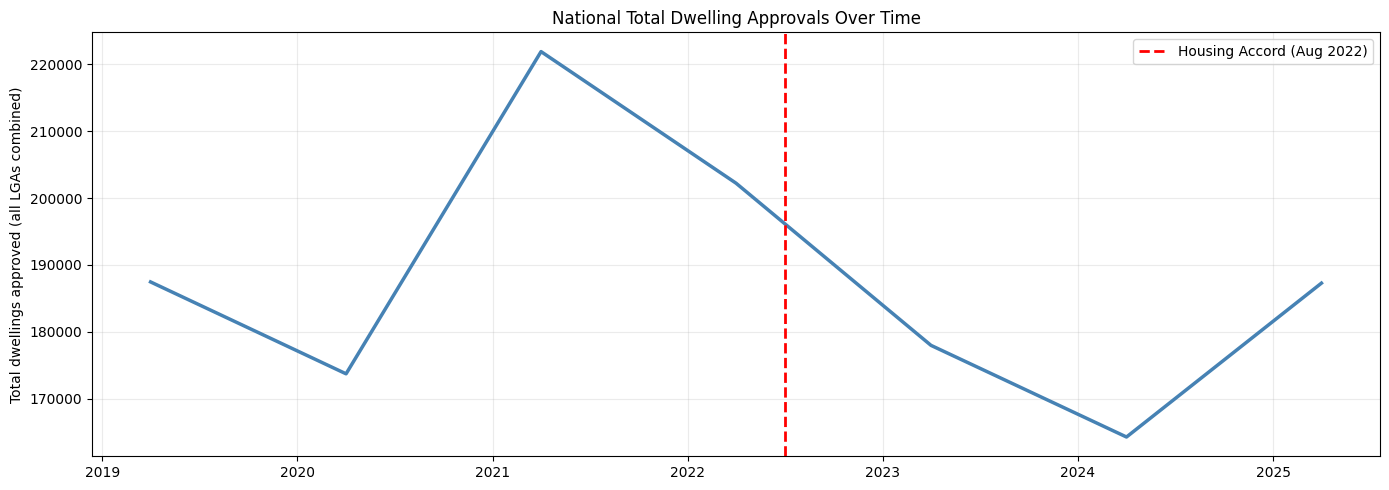

In [23]:
national = df.groupby('quarter')['dwellings_approved'].sum().reset_index()
national['quarter_dt'] = national['quarter'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(national['quarter_dt'], national['dwellings_approved'], color='steelblue', linewidth=2.5)
ax.axvline(pd.Timestamp('2022-07-01'), color='red', linestyle='--', linewidth=2,
           label='Housing Accord (Aug 2022)')
ax.set_title('National Total Dwelling Approvals Over Time')
ax.set_ylabel('Total dwellings approved (all LGAs combined)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. LGA Breakdown: Are More Councils Activating, or Is the Same Handful Doing More?

Section 2 showed the national **total**: the aggregate across all 528 LGAs. But totals can go up two very different ways:

- **More LGAs becoming active**: councils that used to approve 10–20 dwellings per year start approving 100+. This is broad-based supply activation.
- **The same big councils doing more**: a dozen high-volume suburban growth corridors add a few hundred extra, while the rest stay flat. This is concentrated growth.

These are very different stories for housing policy. If the Accord is working as intended, you would expect the first pattern: more councils participating.

The chart below shows how many LGAs fall into each **approval tier** each year, from tiny (<50) to very large (2000+). It answers the composition question: is the pyramid getting taller at the bottom, or just fatter at the top?

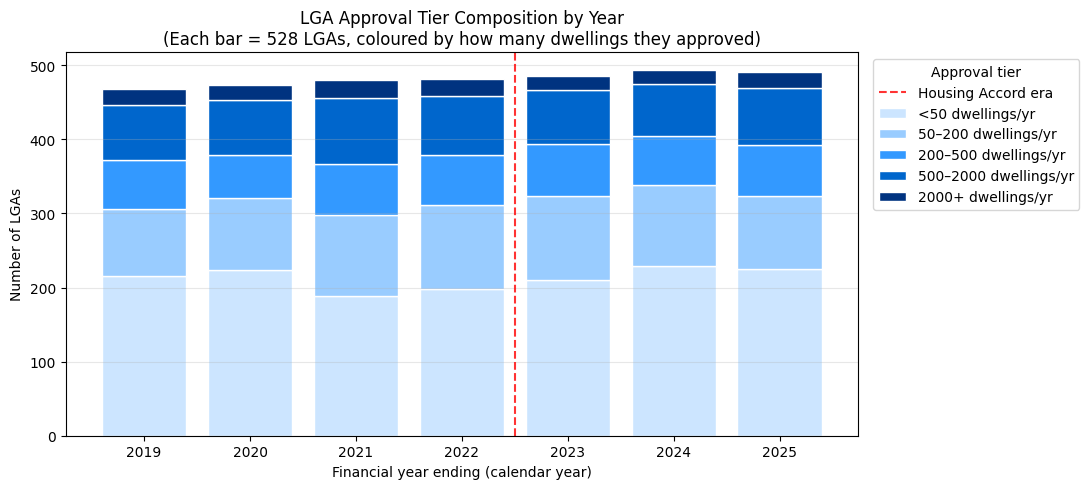

Tier counts for most recent year:
         <50:  225 LGAs (46%)
      50–200:   98 LGAs (20%)
     200–500:   69 LGAs (14%)
    500–2000:   77 LGAs (16%)
       2000+:   22 LGAs (4%)


In [24]:
tiers = [0, 50, 200, 500, 2000, float('inf')]
tier_labels = ['<50', '50–200', '200–500', '500–2000', '2000+']
tier_colors = ['#cce5ff', '#99ccff', '#3399ff', '#0066cc', '#003380']

yearly_tiers = {}
for q in sorted(df['quarter'].unique()):
    year = q.start_time.year
    vals = df[df['quarter'] == q]['dwellings_approved'].values
    counts = [int(np.sum((vals >= lo) & (vals < hi)))
              for lo, hi in zip(tiers[:-1], tiers[1:])]
    yearly_tiers[year] = counts

years = sorted(yearly_tiers.keys())
data = np.array([yearly_tiers[yr] for yr in years])

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(years))
for j, (label, color) in enumerate(zip(tier_labels, tier_colors)):
    bars = ax.bar(range(len(years)), data[:, j], bottom=bottom,
                  label=f'{label} dwellings/yr', color=color, edgecolor='white')
    bottom += data[:, j]

ax.set_xticks(range(len(years)))
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel('Financial year ending (calendar year)')
ax.set_ylabel('Number of LGAs')
ax.axvline(len(years) - len([y for y in years if y >= 2023]) - 0.5,
           color='red', linestyle='--', alpha=0.8, label='Housing Accord era')
ax.set_title('LGA Approval Tier Composition by Year\n'
             '(Each bar = 528 LGAs, coloured by how many dwellings they approved)')
ax.legend(title='Approval tier', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Tier counts for most recent year:')
for label, count in zip(tier_labels, yearly_tiers[years[-1]]):
    pct = count / sum(yearly_tiers[years[-1]]) * 100
    print(f'  {label:>10}: {count:4d} LGAs ({pct:.0f}%)')

## 4. The Headwind: Construction Costs vs Supply Response

Here is the core tension that defines the post-2022 housing environment.

Demand for housing is real and growing, driven by strong overseas migration, household formation, and urban concentration. Councils have the policy signals. And yet: **building homes became dramatically more expensive** in 2021–2022. Post-COVID supply chain disruptions pushed house construction costs up ~15–20% year-on-year, the steepest increase in decades.

When it costs 15% more to build a house than it did last year, several things happen:
- Developers revise project economics. Marginal projects become unviable.
- Builders face margin compression and reduce their pipeline.
- Councils may approve more, but fewer of those approvals convert to actual construction starts.

The chart below overlays dwelling approvals (left axis, blue) against the ABS house construction price index year-on-year change (right axis, orange). **Both axes tell different halves of the same story.**

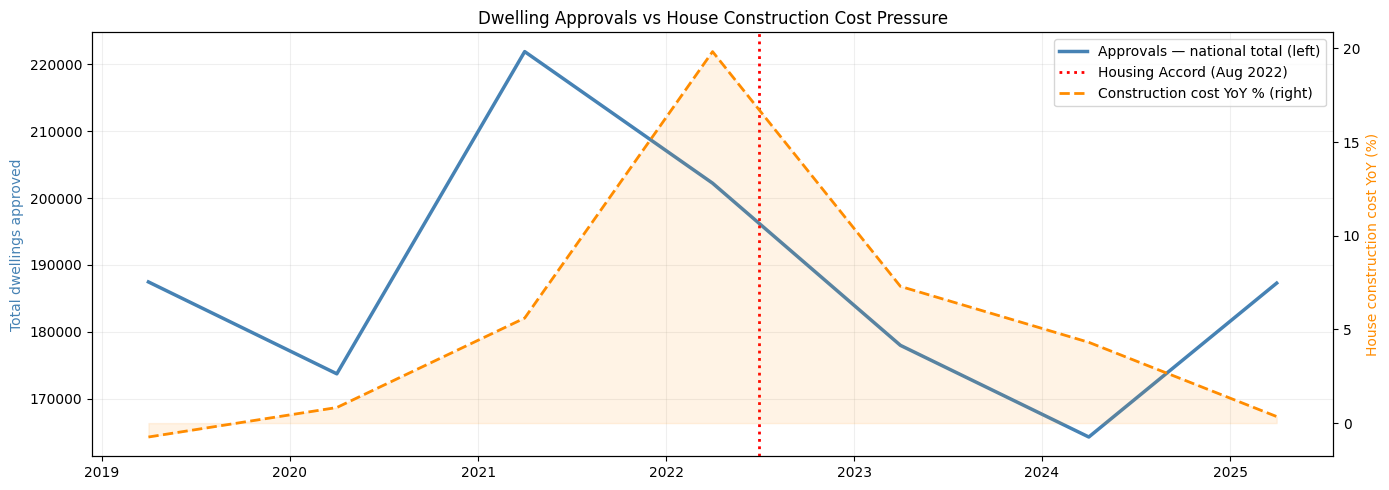

In [25]:
macro = df.drop_duplicates('quarter').sort_values('quarter')[
    ['quarter', 'construction_cost_yoy', 'post_accord_2022']
].copy()
macro['quarter_dt'] = macro['quarter'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(national['quarter_dt'], national['dwellings_approved'],
         color='steelblue', linewidth=2.5, label='Approvals — national total (left)')
ax2.plot(macro['quarter_dt'], macro['construction_cost_yoy'] * 100,
         color='darkorange', linestyle='--', linewidth=2,
         label='Construction cost YoY % (right)')
ax2.fill_between(macro['quarter_dt'], 0, macro['construction_cost_yoy'] * 100,
                 alpha=0.1, color='darkorange')

ax1.axvline(pd.Timestamp('2022-07-01'), color='red', linestyle=':', linewidth=2,
            label='Housing Accord (Aug 2022)')
ax1.set_title('Dwelling Approvals vs House Construction Cost Pressure')
ax1.set_ylabel('Total dwellings approved', color='steelblue')
ax2.set_ylabel('House construction cost YoY (%)', color='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Reading the dual-axis chart

The orange line (construction cost growth) peaked sharply in 2021–2022. The blue line (total approvals) reacted, the timing shows why supply did not surge even when demand was rising.

**Key message:** Construction cost pressure is one of the primary reasons why increasing housing demand does not automatically produce more approvals. Policy can unlock zoning. Finance can provide capital. But when building a standard house costs 15% more than it did last year, developers revise their pipelines regardless of targets.

This is why `construction_cost_yoy` is a model feature and a drift monitoring signal. When costs move far outside the training distribution, the model's learned relationship between demand and approvals may no longer hold.

## 5. The Distribution: What Does a Typical LGA Actually Look Like?

The national total and the tier chart tell the macro story. Here is the micro story: what does the statistical spread of approvals across all 528 LGAs look like in aggregate?

The `describe()` call below gives the key statistics. Look at:
- **Mean vs median** — if mean >> median, the distribution is right-skewed. A few large councils dominate.
- **Std dev** — if this is much larger than the mean, individual LGAs vary enormously.
- **Min / max** — the full range from a tiny rural council to Sydney's outer suburban growth frontier.

In [26]:
from data.pipeline import describe
describe(df)

Time range:     2019Q2 to 2025Q2
LGAs:           528
Total rows:     3371
Target (dwellings_approved):
  mean=390.0  std=853.7  min=1  max=8568
Missing:        none


### What the distribution confirms

With std dev > mean, this is definitively a right-skewed distribution. The **median** LGA approves far fewer dwellings than the mean implies. A handful of outer-suburban growth corridors approve thousands of dwellings per year; the majority of councils approve tens to low hundreds.

This is the design rationale for per-LGA modelling. A single national model trained on the "average" LGA would be trained on an entity that barely exists in the data.

---

## What This Notebook Established

| Chart | What it shows | Key message |
|---|---|---|
| **Section 2** — National total line | Sum of all LGA approvals over time | Australia is below the 60k/quarter Accord pace |
| **Section 3** — LGA tier stacked bars | How many councils per approval tier per year | Most supply comes from a small number of high-volume LGAs |
| **Section 4** — Dual axis chart | Approvals vs construction cost pressure | Cost spikes suppress supply even when demand is high |
| **Section 5** — Describe stats | Statistical distribution of approvals | Distribution is extreme — per-LGA modelling is essential |

Every feature in the forecasting model maps back to something this EDA revealed.

**Next:** `02_drift_case_study.ipynb` — what happens to the model when the construction cost environment shifts dramatically.  
**Or:** `03_project_showcase.ipynb` — the full production pipeline from data to forecast to monitoring.

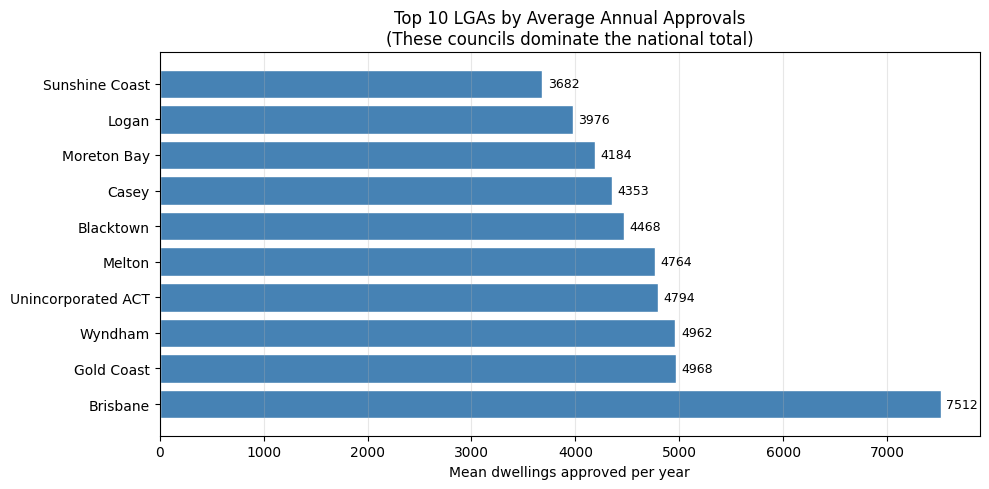

Top 10 LGAs account for 25% of the national approval average


In [27]:
# Top 10 LGAs by average annual approvals — who is carrying the national supply burden?
top_lgas = (
    df.groupby('lga_name')['dwellings_approved']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(top_lgas)), top_lgas.values, color='steelblue', edgecolor='white')
ax.set_yticks(range(len(top_lgas)))
ax.set_yticklabels([f'{c}' for c in top_lgas.index])
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=9)
ax.set_xlabel('Mean dwellings approved per year')
ax.set_title('Top 10 LGAs by Average Annual Approvals\n'
             '(These councils dominate the national total)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

top10_share = top_lgas.sum() / df.groupby('lga_name')['dwellings_approved'].mean().sum() * 100
print(f'Top 10 LGAs account for {top10_share:.0f}% of the national approval average')

### The concentration story

The top 10 LGAs percentage above quantifies exactly how concentrated housing supply is. When that number is high (say >30%), it means a small number of councils are critical bottlenecks — and also the biggest opportunities. If those 10 councils collectively accelerate, the national total moves meaningfully. If they slow down, the Accord gap widens fast.

This is the kind of insight that makes per-LGA forecasting operationally valuable: not just "is national supply enough?" but "which specific councils are underperforming their historical pace — and by how much?"

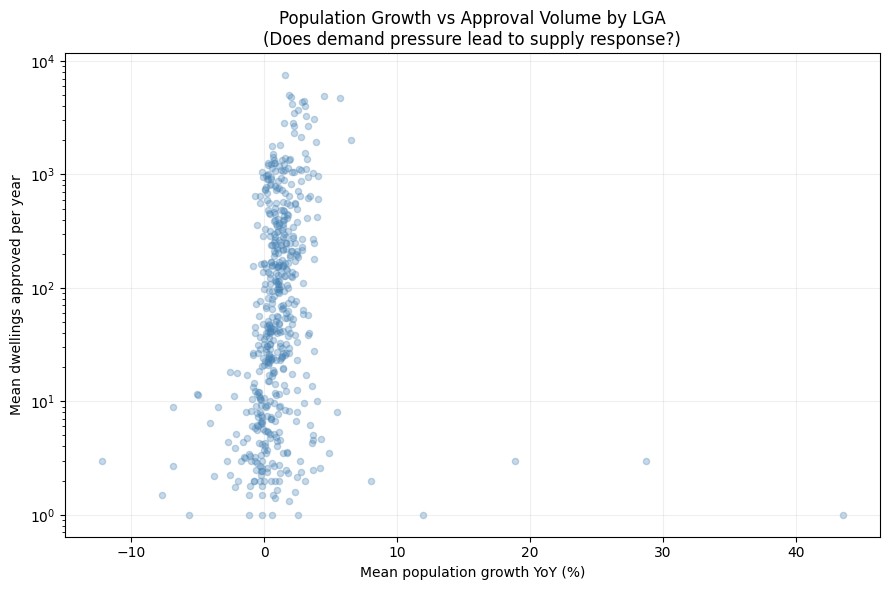

Correlation (population growth vs approvals): 0.137


In [28]:
# Population growth vs approval pace: are the fastest-growing LGAs also approving the most?
pop_vs_approvals = df.groupby('lga_code').agg(
    mean_approvals=('dwellings_approved', 'mean'),
    mean_pop_growth=('population_growth_yoy', 'mean'),
).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(pop_vs_approvals['mean_pop_growth'] * 100,
           pop_vs_approvals['mean_approvals'],
           alpha=0.3, s=20, color='steelblue')
ax.set_xlabel('Mean population growth YoY (%)')
ax.set_ylabel('Mean dwellings approved per year')
ax.set_yscale('log')
ax.set_title('Population Growth vs Approval Volume by LGA\n'
             '(Does demand pressure lead to supply response?)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

corr = pop_vs_approvals.corr().loc['mean_pop_growth', 'mean_approvals']
print(f'Correlation (population growth vs approvals): {corr:.3f}')